In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_data():
    df = pd.read_csv('ecommerce_data.csv')

    # Convert to NumPy arrays
    data = df.to_numpy()

    # Shuffle the data
    np.random.shuffle(data)

    # Split into input (X) and output (y)
    X = data[:, :-1]
    y = data[:, -1].astype(np.int32)

    N, D = X.shape
    X2 = np.zeros((N, D + 3))  # Add a column of ones for bias
    X2[:, :(D-1)] = X[:, :(D-1)] # Non-categorical columns

    # One-hot encode the categorical data
    # Method 1
    # for n in range(N):
    #     t = int(X[n, D-1])
    #     X2[n, t+D-1] = 1

    # Method 2 - More efficient
    Z = np.zeros((N, 4))
    Z[np.arange(N), X[:, D-1].astype(np.int32)] = 1
    X2[:,-4:] = Z
    X = X2

    # Split train and test data
    Xtrain = X[:-100]
    Ytrain = y[:-100]
    Xtest = X[-100:]
    Ytest = y[-100:]

    # Standardize the data - columns 1 and 2
    for i in (1, 2):
        mean_ = Xtrain[:,i].mean()
        std_ = Xtrain[:,i].std()
        Xtrain[:,i] = (Xtrain[:,i] - mean_) / std_
        Xtest[:,i] = (Xtest[:,i] - mean_) / std_

    return Xtrain, Ytrain, Xtest, Ytest


In [3]:
# Define the indicator function
def y2indicator(Y, k):
    N = len(Y)
    ind = np.zeros((N, k))
    for i in range(N):
        ind[i, Y[i]] = 1
    return ind

In [4]:
Xtrain, Ytrain, Xtest, Ytest = get_data()

In [5]:
D = Xtrain.shape[1] # number of features (dimentions)
K = len(set(Ytrain) | set(Ytest)) # number of classes
M = 5 # number of hidden units

# Convert to indicator
Ytrain_ind = y2indicator(Ytrain, K)
Ytest_ind = y2indicator(Ytest, K)

# Randomly initialize weights
W1 = np.random.randn(D, M) / np.sqrt(D)
b1 = np.zeros(M)
W2 = np.random.randn(M, K) / np.sqrt(K)
b2 = np.zeros(K)

In [6]:
# Define softmax function
def softmax(a):
    a -= np.max(a, axis=1, keepdims=True)  # for numerical stability
    expA = np.exp(a)
    A = expA / expA.sum(axis=1, keepdims=True)
    return A

In [7]:
# Forward function for the neural network
def forward(X, W1, b1, W2, b2):
    Z = np.tanh(X.dot(W1) + b1)
    return softmax(Z.dot(W2) + b2), Z

In [8]:
# Predict function for the neural network
def predict(P_Y_given_X):
    return np.argmax(P_Y_given_X, axis=1)

In [9]:
# Classification rate function
def classification_rate(Y, P):
    return np.mean(Y == P)

In [10]:
# Cross-Entropy loss function
def cross_entropy(Y, P_Y_given_X):
    return -np.sum(Y * np.log(P_Y_given_X)) / len(Y)

In [11]:
train_loss = []
test_loss = []
train_acc = []
test_acc = []

learning_rate = 0.01
epochs = 10_000

for epoch in range(epochs):
    P_Y_train, Ztrain = forward(Xtrain, W1, b1, W2, b2)
    P_Y_test, Ztest = forward(Xtest, W1, b1, W2, b2)

    ctrain = cross_entropy(Ytrain_ind, P_Y_train)
    ctest = cross_entropy(Ytest_ind, P_Y_test)

    train_loss.append(ctrain)
    test_loss.append(ctest)

    # Calculate accuracy on the train and test sets
    train_acc.append(classification_rate(Ytrain, predict(P_Y_train)))
    test_acc.append(classification_rate(Ytest, predict(P_Y_test)))

    # Update weights and bias using gradient descent
    dW2 = Ztrain.T.dot(P_Y_train - Ytrain_ind) / len(Ytrain)
    db2 = (P_Y_train - Ytrain_ind).sum(axis=0) / len(Ytrain)
    dZ  = (P_Y_train - Ytrain_ind).dot(W2.T) * (1 - Ztrain * Ztrain)
    dW1 = Xtrain.T.dot(dZ)
    db1 = dZ.sum(axis=0) / len(Ytrain)
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1_000 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch}        Train Loss: {ctrain:.4f}      Test Loss: {ctest:.4f}")

Epoch: 0        Train Loss: 1.5194      Test Loss: 1.5163
Epoch: 1000        Train Loss: 0.2690      Test Loss: 0.3338
Epoch: 2000        Train Loss: 0.2265      Test Loss: 0.2936
Epoch: 3000        Train Loss: 0.1931      Test Loss: 0.2621
Epoch: 4000        Train Loss: 0.1690      Test Loss: 0.2473
Epoch: 5000        Train Loss: 0.1533      Test Loss: 0.2425
Epoch: 6000        Train Loss: 0.1426      Test Loss: 0.2427
Epoch: 7000        Train Loss: 0.1348      Test Loss: 0.2450
Epoch: 8000        Train Loss: 0.1286      Test Loss: 0.2499
Epoch: 9000        Train Loss: 0.1236      Test Loss: 0.2546
Epoch: 9999        Train Loss: 0.1195      Test Loss: 0.2590


In [12]:
# Classification rate on the train and test sets
print(f"Final train classification rate: {classification_rate(Ytrain, predict(P_Y_train)) * 100:.4f}")
print(f"Final test classification rate: {classification_rate(Ytest, predict(P_Y_test)) * 100:.4f}")

Final train classification rate: 97.7500
Final test classification rate: 92.0000


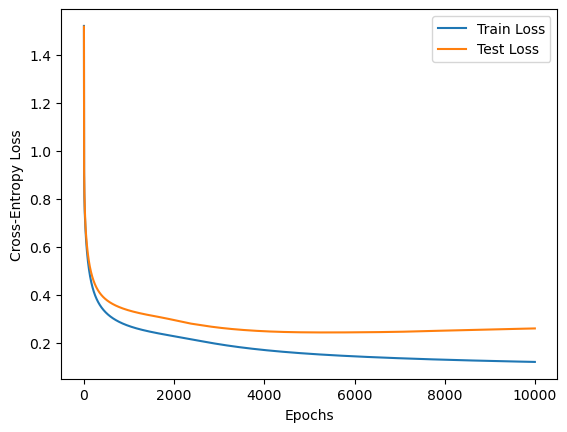

In [13]:
# Plot the loss curves
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.show()

In [14]:
# Final accuracy tests on train and test sets
pYtrain, _ = forward(Xtrain, W1, b1, W2, b2)
pYtest, _ = forward(Xtest, W1, b1, W2, b2)
print(f"Final train accuracy: {classification_rate(Ytrain, predict(pYtrain)) * 100:.4f}%")
print(f"Final test accuracy: {classification_rate(Ytest, predict(pYtest)) * 100:.4f}%")

Final train accuracy: 97.7500%
Final test accuracy: 92.0000%


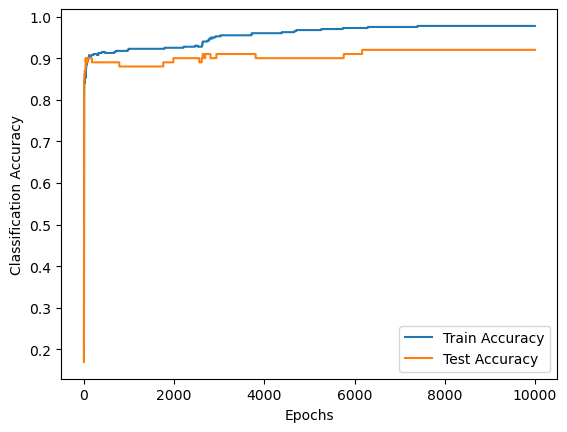

In [15]:
# Plot the train loss and test loss
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Classification Accuracy')
plt.legend()
plt.show()